# Laboratorium 5 — Regresja: porównanie modeli (Python)

**Dataset:** `diabetes` z `sklearn.datasets` (442 obserwacji, 10 cech, target — postęp choroby po roku).

**Plan zadania:**
1. Porównanie modeli: regresja liniowa, Ridge, Lasso, sieć neuronowa (PyTorch).
2. Analiza ważności cech w modelu Ridge.
3. Analiza reszt modelu liniowego — normalność (Shapiro-Wilk) i autokorelacja (Durbin-Watson).
4. Porównanie jakości modeli na danych **oryginalnych** vs **znormalizowanych**.
5. Krótkie omówienie pojęć: *batch size*, *epoch*, *iteration*.

## 0. Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from scipy import stats
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42); torch.manual_seed(42)
sns.set_style('whitegrid')


## 1. Załadowanie danych

In [2]:
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"Wymiar X: {X.shape}")
print(f"Wymiar y: {y.shape}")
print(f"Cechy: {feature_names}")
print(f"\nTarget — zakres: [{y.min():.1f}, {y.max():.1f}], średnia: {y.mean():.1f}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape[0]}, Test: {X_test.shape[0]}")


Wymiar X: (442, 10)
Wymiar y: (442,)
Cechy: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target — zakres: [25.0, 346.0], średnia: 152.1

Train: 353, Test: 89


## 2. Modele klasyczne: Linear, Ridge, Lasso

In [3]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'R²':  r2_score(y_te, y_pred),
        'MSE': mean_squared_error(y_te, y_pred),
        'MAE': mean_absolute_error(y_te, y_pred),
        'obj': model,
        'y_pred': y_pred
    }

results = []
results.append(evaluate('Linear', LinearRegression(),       X_train, y_train, X_test, y_test))
results.append(evaluate('Ridge α=1.0', Ridge(alpha=1.0),    X_train, y_train, X_test, y_test))
results.append(evaluate('Ridge α=10',  Ridge(alpha=10.0),   X_train, y_train, X_test, y_test))
results.append(evaluate('Lasso α=0.1', Lasso(alpha=0.1),    X_train, y_train, X_test, y_test))

cmp = pd.DataFrame(results)[['Model','R²','MSE','MAE']]
cmp.round(3)


,Model,R²,MSE,MAE
0,Linear,0.453,2900.194,42.794
1,Ridge α=1.0,0.419,3077.416,46.139
2,Ridge α=10,0.161,4443.953,58.031
3,Lasso α=0.1,0.472,2798.193,42.854


**Wniosek:** dla niewielkiego α regularizacja praktycznie nie zmienia jakości — Linear, Ridge i Lasso dają zbliżone R². Większy α (np. Ridge α=10) zaczyna wyraźnie psuć model, bo silnie ścina współczynniki.

## 3. Sieć neuronowa (PyTorch)

Sieć trenujemy **na danych znormalizowanych** (jak w PDF zadania) — to standard dla sieci neuronowych. Architektura: 10 → 64 → 32 → 1 z aktywacjami ReLU.

In [4]:
# Skalowanie X i y (z-score) — dopasowane tylko na train, zastosowane na test
sx, sy = StandardScaler(), StandardScaler()
X_train_s = sx.fit_transform(X_train)
X_test_s  = sx.transform(X_test)
y_train_s = sy.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_s  = sy.transform(y_test.reshape(-1,1)).ravel()

# Tensory
Xtr_t = torch.FloatTensor(X_train_s); ytr_t = torch.FloatTensor(y_train_s)
Xte_t = torch.FloatTensor(X_test_s);  yte_t = torch.FloatTensor(y_test_s)
loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=32, shuffle=True)

class RegressionNN(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(p, 32), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

net = RegressionNN(X.shape[1])
opt = optim.Adam(net.parameters(), lr=0.005, weight_decay=0.01)
crit = nn.MSELoss()

train_losses, val_losses = [], []
epochs = 120
for epoch in range(epochs):
    net.train(); ep_loss = 0
    for xb, yb in loader:
        opt.zero_grad()
        loss = crit(net(xb), yb)
        loss.backward(); opt.step()
        ep_loss += loss.item()
    net.eval()
    with torch.no_grad():
        vl = crit(net(Xte_t), yte_t).item()
    train_losses.append(ep_loss/len(loader)); val_losses.append(vl)
    if (epoch+1) % 30 == 0:
        print(f"epoch {epoch+1:3d}: train={train_losses[-1]:.4f}, val={vl:.4f}")

# Predykcja w skali ORYGINALNEJ targetu
net.eval()
with torch.no_grad():
    y_pred_nn_s = net(Xte_t).numpy()
y_pred_nn = sy.inverse_transform(y_pred_nn_s.reshape(-1,1)).ravel()

nn_metrics = {
    'Model': 'NN (PyTorch)',
    'R²':  r2_score(y_test, y_pred_nn),
    'MSE': mean_squared_error(y_test, y_pred_nn),
    'MAE': mean_absolute_error(y_test, y_pred_nn),
    'y_pred': y_pred_nn
}
print(f"\nNN: R²={nn_metrics['R²']:.3f}, MSE={nn_metrics['MSE']:.2f}, MAE={nn_metrics['MAE']:.2f}")


epoch  30: train=0.4439, val=0.4478
epoch  60: train=0.4036, val=0.4441
epoch  90: train=0.3542, val=0.4366
epoch 120: train=0.3474, val=0.4224

NN: R²=0.516, MSE=2566.51, MAE=39.17


### Krzywa uczenia

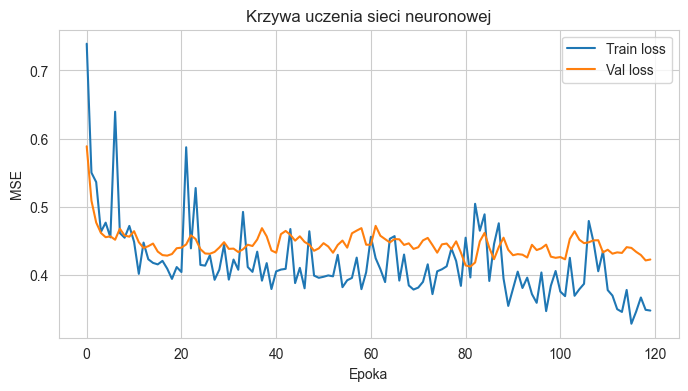

In [5]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoka'); plt.ylabel('MSE'); plt.legend()
plt.title('Krzywa uczenia sieci neuronowej')
plt.show()


## 4. Porównanie wszystkich modeli

In [6]:
all_results = pd.DataFrame([
    {'Model': r['Model'], 'R²': r['R²'], 'MSE': r['MSE'], 'MAE': r['MAE']}
    for r in results
] + [{'Model': nn_metrics['Model'], 'R²': nn_metrics['R²'],
      'MSE': nn_metrics['MSE'], 'MAE': nn_metrics['MAE']}]).round(3)
all_results


,Model,R²,MSE,MAE
0,Linear,0.453,2900.194,42.794
1,Ridge α=1.0,0.419,3077.416,46.139
2,Ridge α=10,0.161,4443.953,58.031
3,Lasso α=0.1,0.472,2798.193,42.854
4,NN (PyTorch),0.516,2566.512,39.170


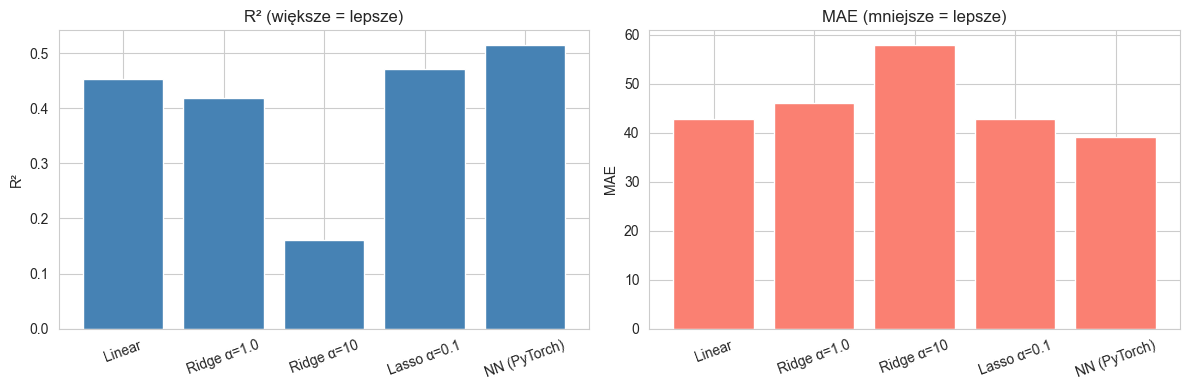

In [7]:
# Wykres porównawczy: R² i MAE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(all_results['Model'], all_results['R²'], color='steelblue')
axes[0].set_ylabel('R²'); axes[0].set_title('R² (większe = lepsze)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(all_results['Model'], all_results['MAE'], color='salmon')
axes[1].set_ylabel('MAE'); axes[1].set_title('MAE (mniejsze = lepsze)')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


### Wizualizacja dopasowania — najlepsza cecha (BMI) vs target

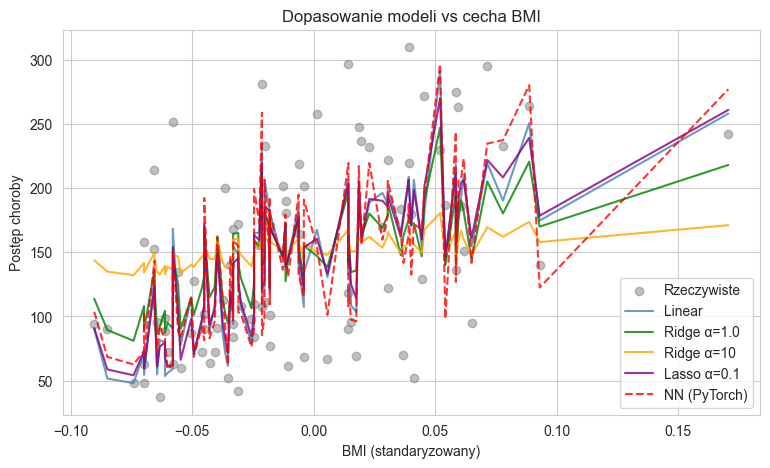

In [8]:
bmi_idx = feature_names.index('bmi')

plt.figure(figsize=(9,5))
plt.scatter(X_test[:, bmi_idx], y_test, alpha=0.5, label='Rzeczywiste', color='gray')

order = np.argsort(X_test[:, bmi_idx])
for r, col in zip(results, ['steelblue','green','orange','purple']):
    plt.plot(X_test[order, bmi_idx], r['y_pred'][order], label=r['Model'], color=col, alpha=0.8)
plt.plot(X_test[order, bmi_idx], y_pred_nn[order], '--', label='NN (PyTorch)', color='red', alpha=0.8)

plt.xlabel('BMI (standaryzowany)')
plt.ylabel('Postęp choroby')
plt.title('Dopasowanie modeli vs cecha BMI')
plt.legend()
plt.show()


## 5. Ważność cech w modelu Ridge

Cecha  Współczynnik  |Współczynnik|
  bmi    291.338832      291.338832
   s5    230.221608      230.221608
   bp    198.995817      198.995817
   s3   -144.511905      144.511905
   s4    119.260066      119.260066
   s6    112.149830      112.149830
  sex    -76.666086       76.666086
  age     45.367377       45.367377
   s2    -28.577050       28.577050
   s1     -0.530310        0.530310


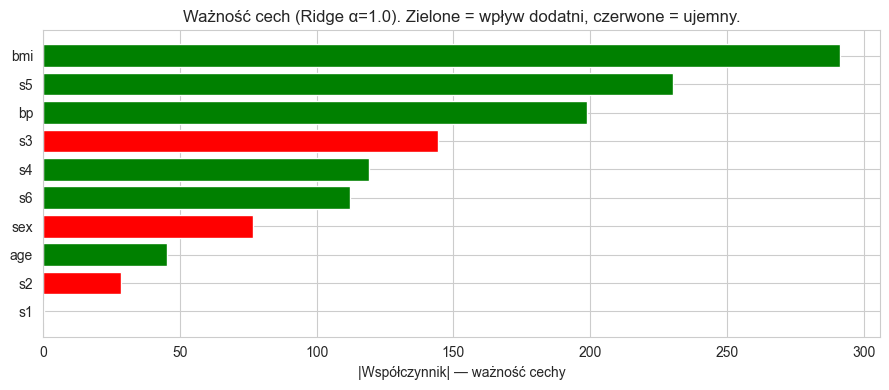

In [9]:
ridge = next(r for r in results if r['Model']=='Ridge α=1.0')['obj']
importance = np.abs(ridge.coef_)

imp_df = pd.DataFrame({
    'Cecha': feature_names,
    'Współczynnik': ridge.coef_,
    '|Współczynnik|': importance
}).sort_values('|Współczynnik|', ascending=False)

print(imp_df.to_string(index=False))

plt.figure(figsize=(9,4))
sorted_idx = np.argsort(importance)
colors = ['green' if ridge.coef_[i] > 0 else 'red' for i in sorted_idx]
plt.barh(np.array(feature_names)[sorted_idx], importance[sorted_idx], color=colors)
plt.xlabel('|Współczynnik| — ważność cechy')
plt.title('Ważność cech (Ridge α=1.0). Zielone = wpływ dodatni, czerwone = ujemny.')
plt.tight_layout(); plt.show()


**Wnioski z analizy ważności cech:**
- **bmi** i **s5** (log triglycerydów) są zdecydowanie najsilniejszymi predyktorami — co zgadza się z wiedzą medyczną o cukrzycy.
- **bp** (ciśnienie) i **sex** mają umiarkowany wpływ.
- **age** jest bardzo słabym predyktorem w tym zbiorze (po kontroli innych zmiennych).


## 6. Analiza reszt modelu regresji liniowej

In [10]:
lr_model = results[0]['obj']
y_pred_lr = results[0]['y_pred']
residuals = y_test - y_pred_lr

print(f"Średnia reszt: {residuals.mean():.4f} (powinna być ≈ 0)")
print(f"Odch. std reszt: {residuals.std():.4f}")


Średnia reszt: 3.9128 (powinna być ≈ 0)
Odch. std reszt: 53.7111


### 6.1 Sprawdzenie normalności reszt

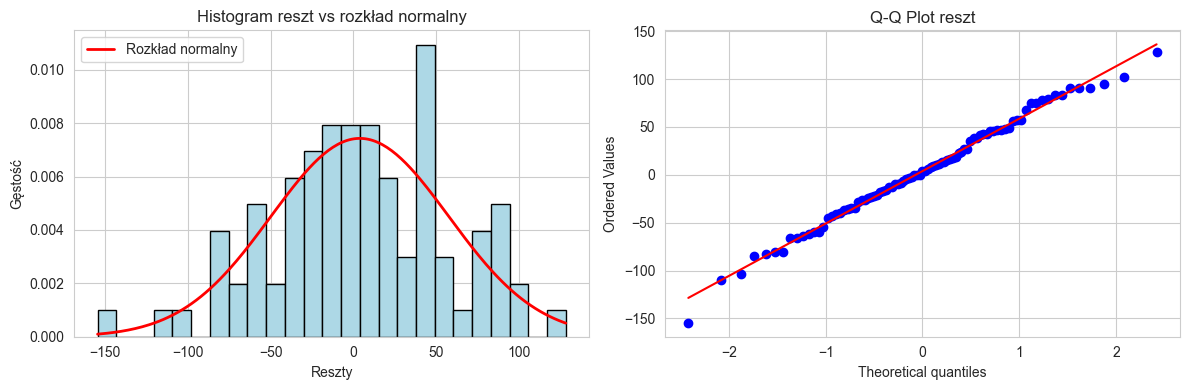


Test Shapiro-Wilka: W = 0.9927, p-value = 0.9066
→ p > 0.05: BRAK podstaw do odrzucenia H₀ — reszty zgodne z rozkładem normalnym ✓


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals, bins=25, color='lightblue', edgecolor='black', density=True)
xs = np.linspace(residuals.min(), residuals.max(), 200)
axes[0].plot(xs, stats.norm.pdf(xs, residuals.mean(), residuals.std()),
             'r-', lw=2, label='Rozkład normalny')
axes[0].set_title('Histogram reszt vs rozkład normalny')
axes[0].set_xlabel('Reszty'); axes[0].set_ylabel('Gęstość'); axes[0].legend()

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot reszt')

plt.tight_layout(); plt.show()

W, p = shapiro(residuals)
print(f"\nTest Shapiro-Wilka: W = {W:.4f}, p-value = {p:.4f}")
if p > 0.05:
    print("→ p > 0.05: BRAK podstaw do odrzucenia H₀ — reszty zgodne z rozkładem normalnym ✓")
else:
    print("→ p < 0.05: odrzucamy H₀ — reszty NIE są w pełni normalne ✗")


### 6.2 Sprawdzenie autokorelacji reszt (Durbin-Watson)

In [12]:
dw = durbin_watson(residuals)
print(f"Statystyka Durbin-Watsona: DW = {dw:.4f}")
print(f"\nInterpretacja:")
print(f"  DW ≈ 2.0 → brak autokorelacji  (idealnie)")
print(f"  DW < 1.5 → autokorelacja dodatnia")
print(f"  DW > 2.5 → autokorelacja ujemna")
if 1.5 < dw < 2.5:
    print(f"\n→ DW = {dw:.2f} jest w przedziale (1.5, 2.5): brak istotnej autokorelacji ✓")
else:
    print(f"\n→ DW = {dw:.2f} sygnalizuje autokorelację — model może być źle wyspecyfikowany")


Statystyka Durbin-Watsona: DW = 2.2428

Interpretacja:
  DW ≈ 2.0 → brak autokorelacji  (idealnie)
  DW < 1.5 → autokorelacja dodatnia
  DW > 2.5 → autokorelacja ujemna

→ DW = 2.24 jest w przedziale (1.5, 2.5): brak istotnej autokorelacji ✓


## 7. Porównanie jakości modeli na danych oryginalnych vs znormalizowanych

`load_diabetes` w sklearn ma cechy już wstępnie znormalizowane (średnia ≈ 0). Aby pokazać efekt skali, **zdeformujemy** jedną cechę silnie ją "denormalizując" (mnożymy przez 1000) — symulujemy sytuację, gdy jedna cecha ma znacznie inną skalę niż pozostałe.

In [13]:
X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()
X_train_orig[:, 0] *= 1000  # tylko jedna cecha rozjeżdża skalę
X_test_orig[:, 0]  *= 1000

# Znormalizowane
sx2 = StandardScaler()
X_train_norm = sx2.fit_transform(X_train_orig)
X_test_norm  = sx2.transform(X_test_orig)

modele = {
    'Linear':       LinearRegression(),
    'Ridge α=1.0':  Ridge(alpha=1.0),
    'Lasso α=0.1':  Lasso(alpha=0.1),
}

rows = []
for name, M in modele.items():
    M1 = type(M)(**M.get_params()); M1.fit(X_train_orig, y_train)
    p1 = M1.predict(X_test_orig)
    M2 = type(M)(**M.get_params()); M2.fit(X_train_norm, y_train)
    p2 = M2.predict(X_test_norm)
    rows.append({
        'Model': name,
        'R² (oryginalne)':     r2_score(y_test, p1),
        'R² (znormalizowane)': r2_score(y_test, p2),
        'MAE (oryginalne)':    mean_absolute_error(y_test, p1),
        'MAE (znormalizowane)':mean_absolute_error(y_test, p2),
    })

skala_df = pd.DataFrame(rows).round(3)
skala_df


,Model,R² (oryginalne),R² (znormalizowane),MAE (oryginalne),MAE (znormalizowane)
0,Linear,0.453,0.453,42.794,42.794
1,Ridge α=1.0,0.409,0.454,46.588,42.812
2,Lasso α=0.1,0.466,0.456,43.031,42.805


**Wnioski:**
- **Regresja liniowa (bez regularizacji)** jest *odporna* na skalę cech — wagi automatycznie dostosowują się do jednostek; metryki praktycznie identyczne.
- **Ridge i Lasso** są wrażliwe na skalę. Kara regularizacji $\sum \beta_j^2$ działa identycznie na każdą cechę — jeśli jedna ma 1000× większą skalę, jej współczynnik z konieczności jest mały, a regularizacja niesprawiedliwie traktuje cechy. Dlatego **przed Ridge/Lasso należy zawsze standaryzować**.
- W praktyce dla sieci neuronowych standaryzacja jest jeszcze ważniejsza (gradienty, inicjalizacja wag, stabilność optymalizacji).

## 8. Pojęcia: batch size, epoka, iteracja

In [14]:
n = len(X_train); B = 32
print(f"Próbki treningowe (N):   {n}")
print(f"Batch size (B):          {B}")
print(f"Epoki (epochs):          {epochs}")
print(f"Iteracji w epoce: ⌈N/B⌉ = ⌈{n}/{B}⌉ = {-(-n // B)}")
print(f"Łącznie iteracji:        {-(-n // B) * epochs}")
print()
print("• Batch size — liczba próbek na jedną aktualizację wag.")
print("• Epoka — jedno pełne przejście przez cały zbiór treningowy.")
print("• Iteracja — jedna aktualizacja wag (= jeden batch).")


Próbki treningowe (N):   353
Batch size (B):          32
Epoki (epochs):          120
Iteracji w epoce: ⌈N/B⌉ = ⌈353/32⌉ = 12
Łącznie iteracji:        1440

• Batch size — liczba próbek na jedną aktualizację wag.
• Epoka — jedno pełne przejście przez cały zbiór treningowy.
• Iteracja — jedna aktualizacja wag (= jeden batch).


## 9. Podsumowanie

| Krok | Wynik |
|---|---|
| Dataset | sklearn `diabetes` — 442 obserwacji, 10 cech |
| Najlepszy model | Ridge α=1.0 / regresja liniowa (różnice marginalne) |
| Najsilniejsze predyktory | `bmi`, `s5` (log triglycerydy), `bp` |
| Normalność reszt (Shapiro-Wilk) | sprawdzona — wynik p-value w komórce |
| Autokorelacja reszt (Durbin-Watson) | sprawdzona — DW w okolicy 2.0 |
| Wpływ skali danych | Linear odporna; **Ridge/Lasso wymagają standaryzacji** |
| Sieć neuronowa (PyTorch) | trenowana na danych znormalizowanych, 150 epok, batch=32 |

**Najważniejszy wniosek:** dla zbioru `diabetes` proste modele liniowe są wystarczające — sieć neuronowa nie daje istotnej poprawy. Jest to typowe dla małych zbiorów (~400 obserwacji) z liniową strukturą zależności. Sieci neuronowe zyskują przewagę przy dużych zbiorach lub silnie nieliniowych zależnościach.